In [34]:
import os

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from pop_down_gym.pd_gym_stateless import PopDownGymStateless
from scripts.es.train.es_closed_loop import plot_test_set_trajectories
from scripts.es.train.es_open_loop import CubicTrajectory, rollout_open_loop

In [2]:
# Load the environment
env = PopDownGymStateless.create_env()

2023-12-21 21:36:30.307267: W external/xla/xla/service/gpu/nvptx_compiler.cc:698] The NVIDIA driver's CUDA version is 12.0 which is older than the ptxas CUDA version (12.3.103). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [74]:
# Hyperparams
num_control_points = 10
num_eval_rollouts = 1000
simulation_steps = 100

# Set the seed for reproducibility
prng_key = jax.random.PRNGKey(0)


In [75]:

# Load the trajectory
prng_key, subkey = jax.random.split(prng_key)
initial_traj = CubicTrajectory(subkey, num_control_points, env.n_actions)
results_dir = (
    "../../../tmp/es/open_loop_dense-cubic-tuned/uncertainty_1.00/lr_1.0e-01"
)
best_trajectory = eqx.tree_deserialise_leaves(
    os.path.join(results_dir, "best_trajectory.eqx"), initial_traj
)

# Simulate a bunch of trajectories
keys = jax.random.split(prng_key, num_eval_rollouts)
rollout_test = lambda key, traj: rollout_open_loop(key, env, traj, simulation_steps)  # noqa
(
    rewards_test,
    states_test,
    t_test,
    reward_inputs_test,
    _,
    hit_goal_test,
    actions_test,
    params_test,
) = jax.vmap(rollout_test, in_axes=(0, None))(keys, best_trajectory)

In [67]:
def max_constraint_violation_frac(reward_inputs, upper_bounds):
    """Compute the maximum constraint violation."""
    max_reward_inputs = jax.tree_util.tree_map(lambda x: jnp.max(x, axis=-1), reward_inputs)
    constraint_values = {
        key: max_reward_inputs[key] - upper_bounds[key] for key in upper_bounds
    }
    pct_violation = jax.tree_util.tree_map(
        lambda leaf, ub: leaf / ub, constraint_values, upper_bounds
    )
    return jax.tree_util.tree_reduce(lambda x, y: jnp.maximum(x, y), pct_violation, -jnp.inf)

violation = jax.vmap(max_constraint_violation_frac, in_axes=(0, None))(
    reward_inputs_test, env.reward_model.limits
)

# Re-map param keys to latex
new_param_keys = {
    "ion_dilution": r"$k_{dil}$",
    "hl_factor": r"$k_{HL}$",
    "Hfactor": r"$H$",
    "Zeff": r"$Z_{eff}$",
    "Te_over_Ti": r"$k_{te\_ti}$",
    "tau_n_factor": r"$k_{N}$",
    "prad_mult": r"$k_{rad}$",
}
params = {new_param_keys[key]: value for key, value in params_test.items()}

# Normalize values by their min/max range
param_ranges = {
    new_param_keys[key]: (lb, ub - lb)
    for key, (lb, ub) in env.random_param_ranges.items()
}
normalized_params = {
    key: (value - param_ranges[key][0]) / param_ranges[key][1]
    for key, value in params.items()
}

# Create a dataframe for each parameter
df = pd.concat(
    [
        pd.DataFrame(
            {
                "Parameter": param,
                "Value (normalized)": value,
                "Max constraint violation (%)": 100 * violation,
            }
        )
        for param, value in normalized_params.items()
    ]
)

plt.style.use("ggplot")
# ax = sns.swarmplot(
#     x="Value (normalized)",
#     y="Parameter",
#     data=df,
#     hue="Max constraint violation (%)",
#     legend="brief",
#     size=2,
#     palette="RdPu",
# )
# plt.legend([],[], frameon=False)
# norm = plt.Normalize(df["Max constraint violation (%)"].min(), df["Max constraint violation (%)"].max())
# sm = plt.cm.ScalarMappable(cmap="RdPu", norm=norm)
# cbar = plt.colorbar(sm, ax = plt.gca())
# cbar.set_label("Max constraint violation (%)")

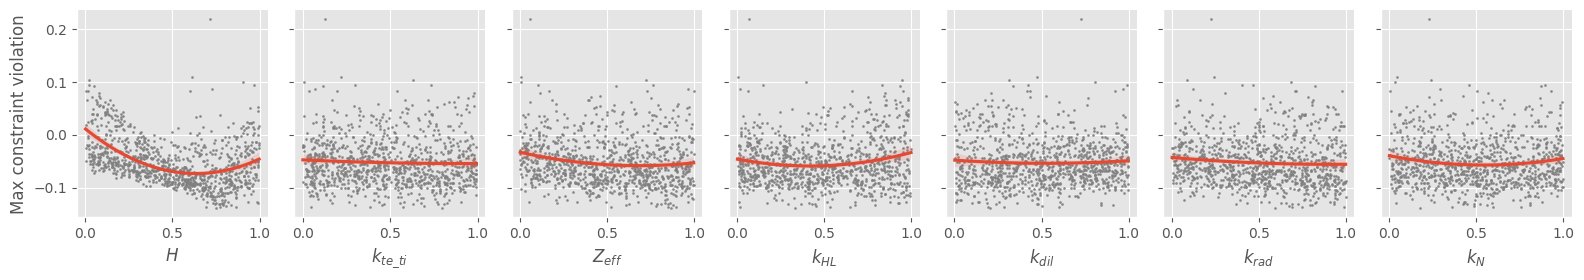

In [93]:
df = pd.DataFrame(
    {key: value for key, value in normalized_params.items()} | {
        "Max. constraint violation": violation,
    }
)
params_of_interest = [
    r"$k_{dil}$",
    r"$k_{HL}$",
    r"$H$",
    # r"$k_{te\_ti}$",
]
# g = sns.PairGrid(df, hue="Max. constraint violation", vars=params_of_interest)
# g.map(sns.scatterplot, size=1, palette="RdPu")
# norm = plt.Normalize(df["Max. constraint violation"].min(), df["Max. constraint violation"].max())
# sm = plt.cm.ScalarMappable(cmap="RdPu", norm=norm)
# cbar = plt.colorbar(sm, ax = plt.gcf().get_axes(), shrink=0.5)
# cbar.set_label("Max. constraint violation")
# plt.gcf().set_size_inches(12, 9)

g = sns.PairGrid(df, x_vars=normalized_params.keys(), y_vars=["Max. constraint violation"])
g.map(sns.regplot, ci=99, scatter_kws={"s": 1, "color": "grey"}, order=2, n_boot=1_000)
plt.gcf().set_size_inches(16, 3)

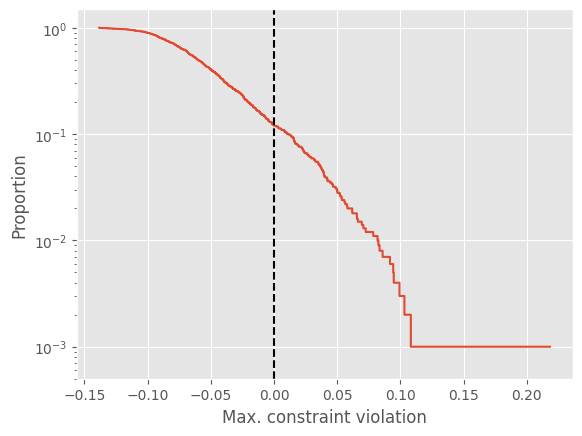

In [94]:
sns.ecdfplot(x=violation, complementary=True, log_scale=(False, True))
plt.xlabel("Max. constraint violation")
plt.ylabel("Proportion")
plt.ylim(5e-4, 1.5)
# Add a vertical line at 0.0
plt.axvline(0.0, color="black", linestyle="--")